# Эксперимент 2.4
Сравнение методов на ML (`лаб2.pdf`, п. 2.4).


In [1]:
%load_ext autoreload
%autoreload 2


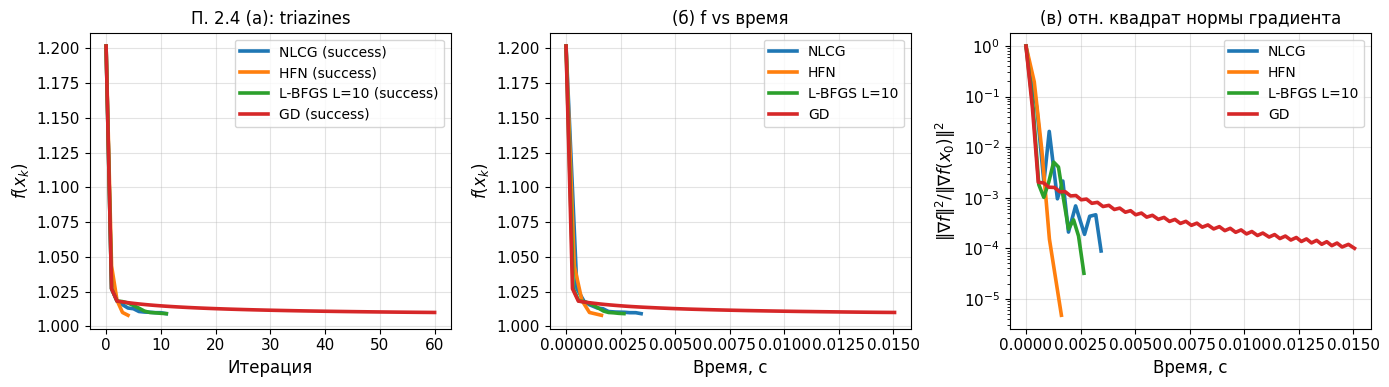

In [2]:
%matplotlib inline
import sys
import time
from pathlib import Path

_root = Path.cwd().resolve()
if _root.name == "notebooks":
    _root = _root.parent
_src = _root / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

import matplotlib.pyplot as plt
import numpy as np
from experiments_common import (
    TimedOracle,
    init_notebook,
    load_a1a,
    load_triazines,
    make_classification_oracle,
    make_regression_oracle,
    savefig_both,
    standard_regcoef,
    train_test_oracles_regression,
)
from ml_tools import sparse_oracle_ops
from optimization import (
    gradient_descent,
    hessian_free_newton,
    lbfgs,
    newton,
    newton_modified,
    nonlinear_conjugate_gradients,
    trust_region_steihaug_newton,
)
from oracles import NonConvexOracle, QuadraticOracle, beale_mesh_Z

init_notebook()

Xr, yr = load_triazines()
mr = Xr.shape[0]
reg = standard_regcoef(mr)
oracle = make_regression_oracle(Xr, yr, reg)
n = Xr.shape[1]
x0 = np.zeros(n)
tol = 1e-4
line = {"method": "Wolfe", "alpha_0": 1.0}
runners = [
    ("NLCG", lambda o, x0: nonlinear_conjugate_gradients(o, x0, tolerance=tol, line_search_options=line, trace=True)),
    ("HFN", lambda o, x0: hessian_free_newton(o, x0, tolerance=tol, line_search_options=line, trace=True)),
    ("L-BFGS L=10", lambda o, x0: lbfgs(o, x0, tolerance=tol, memory_size=10, line_search_options=line, trace=True)),
    ("GD", lambda o, x0: gradient_descent(o, x0, tolerance=tol, line_search_options=line, trace=True)),
]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for name, fn in runners:
    _, msg, h = fn(oracle, x0)
    if h is None:
        continue
    it = np.arange(len(h["func"]))
    axes[0].plot(it, h["func"], label="{} ({})".format(name, msg))
    axes[1].plot(h["time"], h["func"], label=name)
    g0 = float(np.linalg.norm(oracle.grad(x0)) ** 2)
    rel = [float(g) ** 2 / g0 for g in h["grad_norm"]]
    axes[2].semilogy(h["time"], rel, label=name)
axes[0].set_xlabel("Итерация")
axes[0].set_ylabel(r"$f(x_k)$")
axes[0].set_title("П. 2.4 (а): triazines")
axes[0].legend()
axes[1].set_xlabel("Время, с")
axes[1].set_ylabel(r"$f(x_k)$")
axes[1].set_title("(б) f vs время")
axes[1].legend()
axes[2].set_xlabel("Время, с")
axes[2].set_ylabel(r"$\|\nabla f\|^2/\|\nabla f(x_0)\|^2$")
axes[2].set_title("(в) отн. квадрат нормы градиента")
axes[2].legend()
fig.tight_layout()
savefig_both(fig, "exp24_triazines_methods")
plt.show()
